# Practical Statistics for Data Scientists
# AI-Assisted Statistics for Data Scientists
# Chapter 4: Regression and Prediction
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from mlxtend.feature_selection import SequentialFeatureSelector
from pygam import LinearGAM, s, l
from scipy.stats import linregress
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.gam.api import GLMGam, BSplines
from statsmodels.stats.outliers_influence import OLSInfluence
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../../data')


## Regression and Prediction
### Simple Linear Regression
#### The Regression Equation

In [1]:
lung = pd.read_csv(DATA_DIR / "LungDisease.csv")

predictors = ["Exposure"]
outcome = "PEFR"

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient Exposure: {model.coef_[0]:.3f}")

Intercept: 424.583
Coefficient Exposure: -4.185


#### Fitted Values and Residuals

In [1]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

### Multiple Linear Regression
#### Example: King County Housing Data

In [1]:
house = pd.read_csv(DATA_DIR / "house_sales.csv")

subset = ["AdjSalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms",
          "Bedrooms", "BldgGrade"]
house[subset].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
0,300805.0,2400,9373,3.00,6,7
1,1076162.0,3764,20156,3.75,4,10
2,761805.0,2060,26036,1.75,4,8
3,442065.0,3200,8618,3.75,5,7
4,297065.0,1720,8620,1.75,4,7


In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1]:
print(f"Intercept: {house_lm.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(house_lm.feature_names_in_, house_lm.coef_, strict=True):
    print(f" {name}: {coef}")

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240785
 SqFtLot: -0.060466820653060145
 Bathrooms: -19442.840398321074
 Bedrooms: -47769.9551852142
 BldgGrade: 106106.96307898112


#### Assessing the Model

In [1]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f"RMSE: {RMSE:.0f}")
print(f"r2: {r2:.4f}")

RMSE: 261220
r2: 0.5406


In [1]:
model = sm.OLS(house[outcome], sm.add_constant(house[predictors]))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:18:15   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -5.219e+05   1.57e+04    -33.342      0.000   -5.53e+05   -4.91e+05
SqFtTotLiving   228.8306      3.899     58.694      0.000     221.189     236.472
SqFtLot          -0.0605      0.061     -0.988      0.323      -0.180       0.059
Bathrooms     -1.944e+04   3625.388     -5.363      0.000   -2.65e+04   -1.23e+04
Bedrooms      -4.777e+04   2489.732    -19.187      0.000   -5.27e+04   -4.29e+04
BldgGrade      1.061e+05   2396.445     44.277      0.000    1.01e+05    1.11e+05
==============================================================================
Omnibus:                    29676.557   Durbin-Watson:                   1.247
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         19390738.346
Skew:                           6.889   Prob(JB):                         0.00
Kurtosis:                     145.559   Cond. No.                     2.86e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Model Selection and Stepwise Regression

In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade",
              "PropertyType", "NbrLivingUnits", "SqFtFinBasement", "YrBuilt",
              "YrRenovated", "NewConstruction"]

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X["NewConstruction"] = [1 if nc else 0 for nc in X["NewConstruction"]]

house_full = sm.OLS(house[outcome], sm.add_constant(X))
results = house_full.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:18:15   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       6.182e+06   1.55e+05     39.902      0.000    5.88e+06    6.49e+06
SqFtTotLiving                198.6364      4.234     46.920      0.000     190.338     206.934
SqFtLot                        0.0771      0.058      1.330      0.184      -0.037       0.191
Bathrooms                   4.286e+04   3808.114     11.255      0.000    3.54e+04    5.03e+04
Bedrooms                   -5.187e+04   2396.904    -21.638      0.000   -5.66e+04   -4.72e+04
BldgGrade                   1.373e+05   2441.242     56.228      0.000    1.32e+05    1.42e+05
NbrLivingUnits              5723.8438   1.76e+04      0.326      0.744   -2.87e+04    4.01e+04
SqFtFinBasement                7.0611      4.627      1.526      0.127      -2.009      16.131
YrBuilt                    -3574.2210     77.228    -46.282      0.000   -3725.593   -3422.849
YrRenovated                   -2.5311      3.924     -0.645      0.519     -10.222       5.160
NewConstruction            -2489.1122   5936.692     -0.419      0.675   -1.41e+04    9147.211
PropertyType_Single Family  2.997e+04   2.61e+04      1.149      0.251   -2.12e+04    8.11e+04
PropertyType_Townhouse      9.286e+04    2.7e+04      3.438      0.001    3.99e+04    1.46e+05
==============================================================================
Omnibus:                    31006.128   Durbin-Watson:                   1.393
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         26251977.078
Skew:                           7.427   Prob(JB):                         0.00
Kurtosis:                     168.984   Cond. No.                     2.98e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.98e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [1]:
sfs_stepwise = SequentialFeatureSelector(LinearRegression(),
    k_features=(1, 11),
    forward=True, floating=True,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

sfs_stepwise.fit(X, house[outcome])
print(sfs_stepwise.k_feature_names_)

('SqFtTotLiving', 'Bathrooms', 'Bedrooms', 'BldgGrade', 'YrBuilt', 'PropertyType_Single Family', 'PropertyType_Townhouse')


In [1]:
step_lm = Pipeline([
    ("sfs", SequentialFeatureSelector(LinearRegression(),
        k_features=(1, 12), forward=False, floating=True,
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)),
    ("model", LinearRegression()),
])
step_lm.fit(X, house[outcome])

/Users/petergedeck/cdd/practical-statistics-for-data-scientists-code-3e/.venv/lib/python3.13/site-packages/sklearn/externals/_numpydoc/docscrape.py:203: UserWarning: potentially wrong underline length... 
Examples 
----------- in 
Sequential Feature Selection for Classification and Regression.
...
  while not self._is_at_section() and not self._doc.eof():


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('sfs', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,estimator,LinearRegression()
,k_features,"(1, ...)"
,forward,False
,floating,True
,verbose,0
,scoring,'neg_root_mean_squared_error'
,cv,5


#### Weighted Regression

In [1]:
house["Year"] = [int(date.split("-")[0]) for date in house.DocumentDate]
house["Weight"] = house.Year - 2005

In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1]:
pd.concat([
    pd.DataFrame({
        "predictor": predictors,
        "house_lm": house_lm.coef_,
        "house_wt": house_wt.coef_,
    }),
    pd.DataFrame({
        "predictor": ["intercept"],
        "house_lm": house_lm.intercept_,
        "house_wt": house_wt.intercept_,
    }),
])

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


### Factor Variables in Regression
#### Dummy Variables Representation

In [1]:
house.PropertyType.head()

0        Multiplex
1    Single Family
2    Single Family
3    Single Family
4    Single Family
Name: PropertyType, dtype: str

In [1]:
print(pd.get_dummies(house["PropertyType"]).head())
print(pd.get_dummies(house["PropertyType"], drop_first=True).head())

   Multiplex  Single Family  Townhouse
0       True          False      False
1      False           True      False
2      False           True      False
3      False           True      False
4      False           True      False
   Single Family  Townhouse
0          False      False
1           True      False
2           True      False
3           True      False
4           True      False


In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms",
              "BldgGrade", "PropertyType"]

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f"Intercept: {house_lm_factor.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(X.columns, house_lm_factor.coef_, strict=True):
    print(f" {name}: {coef}")

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.37362892503833
 SqFtLot: -0.07036798136811658
 Bathrooms: -15979.013473415354
 Bedrooms: -50889.73218483002
 BldgGrade: 109416.30516146205
 PropertyType_Single Family: -84678.21629549282
 PropertyType_Townhouse: -115121.97921609184


#### Factor Variables with Many Levels

In [1]:
pd.DataFrame(house["ZipCode"].value_counts()).transpose()

ZipCode,98038,98103,98042,98115,98117,98052,98034,98033,98059,98074,...,98051,98024,98354,98050,98057,98288,98224,98068,98113,98043
count,788,671,641,620,619,614,575,517,513,502,...,32,31,9,7,4,4,3,1,1,1


In [1]:
house = pd.read_csv(DATA_DIR / "house_sales.csv")
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"
house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

zip_groups = pd.DataFrame([
    *pd.DataFrame({
        "ZipCode": house["ZipCode"],
        "residual": house[outcome] - house_lm.predict(house[predictors]),
    })
    .groupby(["ZipCode"])[["ZipCode", "residual"]]
    .apply(lambda x: {
        "ZipCode": x.iloc[0, 0],
        "count": len(x),
        "median_residual": x.residual.median(),
    }),
]).sort_values("median_residual")
zip_groups["cum_count"] = np.cumsum(zip_groups["count"])
zip_groups["ZipGroup"] = pd.qcut(zip_groups["cum_count"], 5, labels=False,
                                 retbins=False)

to_join = zip_groups[["ZipCode", "ZipGroup"]].set_index("ZipCode")
house = house.join(to_join, on="ZipCode")
house["ZipGroup"] = house["ZipGroup"].astype("category")

In [1]:
print(zip_groups.head())
print(zip_groups.ZipGroup.value_counts().sort_index())

    ZipCode  count  median_residual  cum_count  ZipGroup
36    98057      4   -537321.644462          4         0
27    98043      1   -307661.343614          5         0
46    98092    289   -193569.183599        294         0
23    98038    788   -150066.477035       1082         0
31    98051     32   -142352.869593       1114         0
ZipGroup
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


### Interpreting the Regression Equation
#### Correlated Predictors

In [1]:
print(f"Intercept: {step_lm.named_steps['model'].intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(step_lm.named_steps["sfs"].k_feature_names_,
                      step_lm.named_steps["model"].coef_, strict=True):
    print(f"  {name}: {coef}")

Intercept: 6259055.855
Coefficients:
  SqFtTotLiving: 201.65789971342235
  Bathrooms: 42787.933811708994
  Bedrooms: -51742.8382076272
  BldgGrade: 136309.59662237618
  YrBuilt: -3605.8233277869685
  PropertyType_Single Family: 24105.25018215709
  PropertyType_Townhouse: 87589.26527129347


In [1]:
predictors = ["Bedrooms", "BldgGrade", "PropertyType", "YrBuilt"]
outcome = "AdjSalePrice"

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1]:
print(f"Intercept: {reduced_lm.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(X.columns, reduced_lm.coef_, strict=True):
    print(f" {name}: {coef}")

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.53723021958
 BldgGrade: 248997.7936621269
 YrBuilt: -3211.7448621551166
 PropertyType_Single Family: -19898.49534050195
 PropertyType_Townhouse: -47355.43687334422


#### Confounding Variables

In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms",
              "BldgGrade", "PropertyType", "ZipGroup"]
outcome = "AdjSalePrice"

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])

print(f"Intercept: {confounding_lm.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(X.columns, confounding_lm.coef_, strict=True):
    print(f" {name}: {coef}")

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005580163
 SqFtLot: 0.4549871385466008
 Bathrooms: 5928.425640001413
 Bedrooms: -41682.871840744534
 BldgGrade: 98541.18352725999
 PropertyType_Single Family: 19323.625287919574
 PropertyType_Townhouse: -78198.72092762378
 ZipGroup_1: 53317.17330659807
 ZipGroup_2: 116251.5888356354
 ZipGroup_3: 178360.53178793358
 ZipGroup_4: 338408.6018565202


#### Interactions and Main Effects

In [1]:
model = smf.ols(formula="AdjSalePrice ~ SqFtTotLiving*ZipGroup + SqFtLot + "
     "Bathrooms + Bedrooms + BldgGrade + PropertyType", data=house)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:18:23   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                     -4.853e+05   2.05e+04    -23.701      0.000   -5.25e+05   -4.45e+05
ZipGroup[T.1]                 -1.113e+04   1.34e+04     -0.830      0.407   -3.74e+04    1.52e+04
ZipGroup[T.2]                  2.032e+04   1.18e+04      1.717      0.086   -2877.441    4.35e+04
ZipGroup[T.3]                   2.05e+04   1.21e+04      1.697      0.090   -3180.870    4.42e+04
ZipGroup[T.4]                 -1.499e+05   1.13e+04    -13.285      0.000   -1.72e+05   -1.28e+05
PropertyType[T.Single Family]  1.357e+04   1.39e+04      0.975      0.330   -1.37e+04    4.09e+04
PropertyType[T.Townhouse]     -5.884e+04   1.51e+04     -3.888      0.000   -8.85e+04   -2.92e+04
SqFtTotLiving                   114.7650      4.863     23.600      0.000     105.233     124.297
SqFtTotLiving:ZipGroup[T.1]      32.6043      5.712      5.708      0.000      21.409      43.799
SqFtTotLiving:ZipGroup[T.2]      41.7822      5.187      8.056      0.000      31.616      51.948
SqFtTotLiving:ZipGroup[T.3]      69.3415      5.619     12.341      0.000      58.329      80.354
SqFtTotLiving:ZipGroup[T.4]     226.6836      4.820     47.032      0.000     217.237     236.131
SqFtLot                           0.6869      0.052     13.296      0.000       0.586       0.788
Bathrooms                     -3619.4533   3202.296     -1.130      0.258   -9896.174    2657.267
Bedrooms                       -4.18e+04   2120.279    -19.715      0.000    -4.6e+04   -3.76e+04
BldgGrade                      1.047e+05   2069.472     50.592      0.000    1.01e+05    1.09e+05
==============================================================================
Omnibus:                    30927.394   Durbin-Watson:                   1.581
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         34361794.502
Skew:                           7.279   Prob(JB):                         0.00
Kurtosis:                     193.101   Cond. No.                     5.80e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.8e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Regression Diagnostics
#### Outliers

In [1]:
house_98105 = house.loc[house["ZipCode"] == 98105, ]

predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"

house_outlier = sm.OLS(house_98105[outcome],
                       sm.add_constant(house_98105[predictors]))
result_98105 = house_outlier.fit()

In [1]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal
sresiduals.idxmin(), sresiduals.min()

(np.int64(20428), np.float64(-4.326731804078573))

In [1]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print("AdjSalePrice", outlier[outcome])
print(outlier[predictors])

AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 20428, dtype: object


#### Influential Values

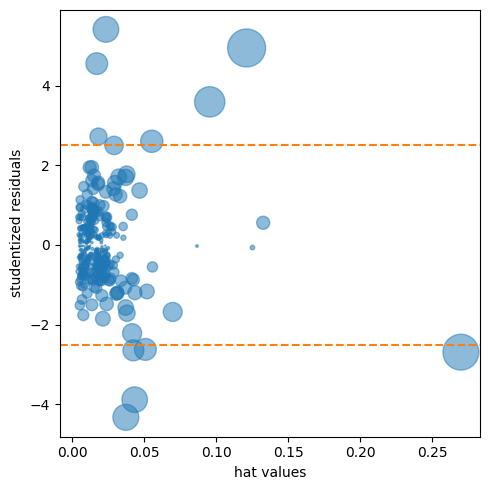

In [1]:
influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle="--", color="C1")
ax.axhline(2.5, linestyle="--", color="C1")
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal,
           s=1000 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)
ax.set_xlabel("hat values")
ax.set_ylabel("studentized residuals")

plt.tight_layout()
plt.show()

In [1]:
mask = [dist < 0.08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(house_infl[outcome], sm.add_constant(house_infl[predictors]))
result_infl = ols_infl.fit()

pd.DataFrame({
    "Original": result_98105.params,
    "Influential removed": result_infl.params,
})

,Original,Influential removed
const,-772549.862447,-647137.096716
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737


#### Heteroskedasticity, Nonnormality, and Correlated Errors

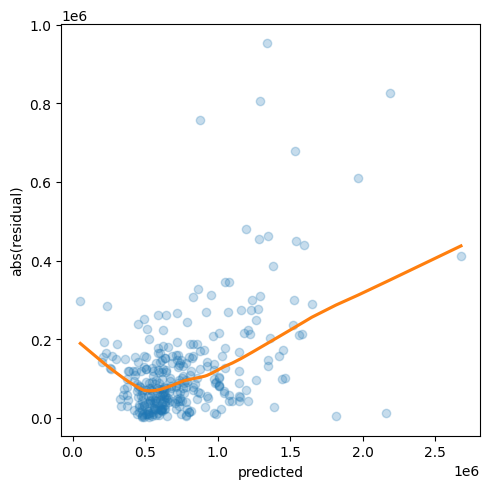

In [1]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid),
            scatter_kws={"alpha": 0.25}, line_kws={"color": "C1"},
            lowess=True, ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("abs(residual)")

plt.tight_layout()
plt.show()

#### Partial Residual Plots and Nonlinearity

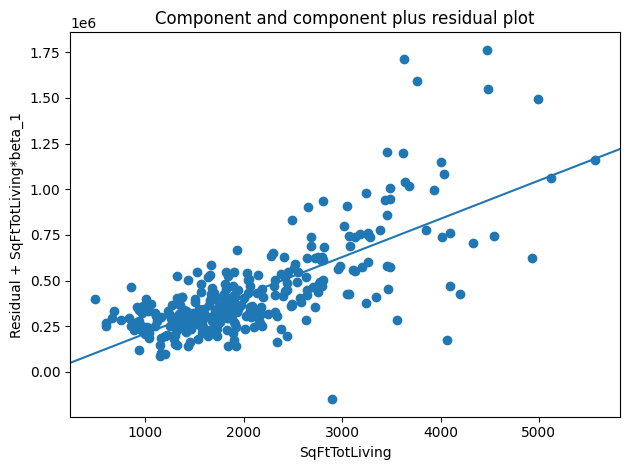

In [1]:
sm.graphics.plot_ccpr(result_98105, "SqFtTotLiving")

plt.tight_layout()
plt.show()

### Polynomial and Spline Regression
#### Polynomial

In [1]:
model_poly = smf.ols(formula="AdjSalePrice ~  SqFtTotLiving + "
                "I(SqFtTotLiving**2) + "
                "SqFtLot + Bathrooms + Bedrooms + BldgGrade", data=house_98105)
result_poly = model_poly.fit()
result_poly.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          9.95e-106
Time:                        18:18:24   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -6.159e+05   1.03e+05     -5.953      0.000   -8.19e+05   -4.12e+05
SqFtTotLiving             7.4521     55.418      0.134      0.893    -101.597     116.501
I(SqFtTotLiving ** 2)     0.0388      0.010      4.040      0.000       0.020       0.058
SqFtLot                  32.5594      5.436      5.990      0.000      21.863      43.256
Bathrooms             -1435.1231   1.95e+04     -0.074      0.941   -3.99e+04     3.7e+04
Bedrooms              -9191.9441   1.33e+04     -0.693      0.489   -3.53e+04    1.69e+04
BldgGrade              1.357e+05   1.49e+04      9.087      0.000    1.06e+05    1.65e+05
==============================================================================
Omnibus:                       75.161   Durbin-Watson:                   1.625
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              637.978
Skew:                           0.699   Prob(JB):                    2.92e-139
Kurtosis:                       9.853   Cond. No.                     7.37e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.37e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Splines

In [1]:
formula = ("AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + "
           "SqFtLot + Bathrooms + Bedrooms + BldgGrade")
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()

#### Generalized Additive Models

In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"
X = house_98105[predictors].to_numpy()
y = house_98105[outcome]

gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
print(gam.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -4213.0332
Number of Samples:                          313 AIC:                                             8443.4209
                                                AICc:                                            8443.9746
                                                GCV:                                      30838885095.1688
                                                Scale:                                         171698.5198
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

/var/folders/_8/ms0ft4913k3290v7f0g_yfpc0000gn/T/ipykernel_27334/4156786098.py:8: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


# Supplementary Material
## Figure 4-1. Cotton exposure versus lung capacity

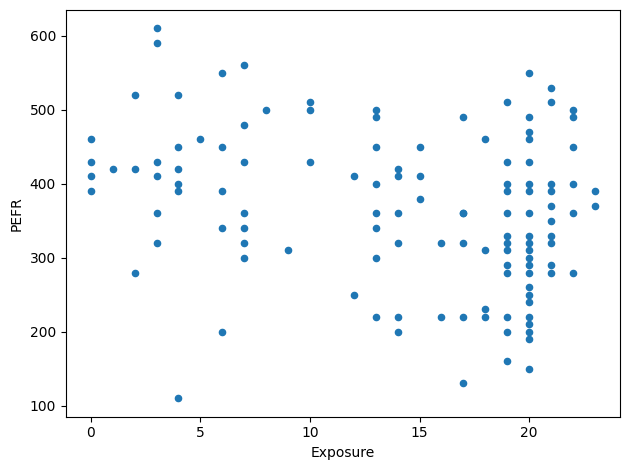

In [1]:
lung = pd.read_csv(DATA_DIR / "LungDisease.csv")

lung.plot.scatter(x="Exposure", y="PEFR")

plt.tight_layout()
plt.show()

## Figure 4-2. Slope and intercept for the regression fit to the lung data

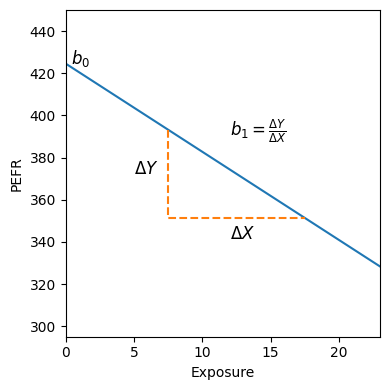

In [1]:
predictors = ["Exposure"]
outcome = "PEFR"
model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel("Exposure")
ax.set_ylabel("PEFR")
ax.plot((0, 23), model.predict(pd.DataFrame({"Exposure": [0, 23]})))
ax.text(0.4, model.intercept_, r"$b_0$", size="larger")

x = pd.DataFrame({"Exposure": [7.5, 17.5]})
y = model.predict(x)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), "--")
ax.text(5, np.mean(y), r"$\Delta Y$", size="larger")
ax.text(12, y[1] - 10, r"$\Delta X$", size="larger")
ax.text(12, 390, r"$b_1 = \frac{\Delta Y}{\Delta X}$", size="larger")

plt.tight_layout()
plt.show()

## Figure 4-3. Residuals for the regression fit to the lung data

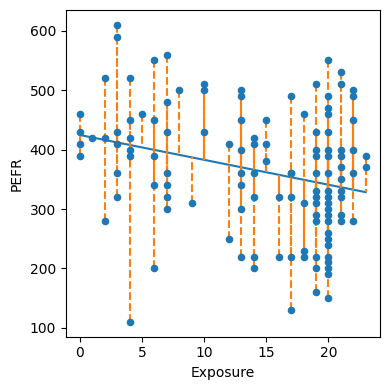

In [1]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

ax = lung.plot.scatter(x="Exposure", y="PEFR", figsize=(4, 4), zorder=10)
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted, strict=True):
    ax.plot((x, x), (yactual, yfitted), "--", color="C1")

plt.tight_layout()
plt.show()

## Figure 4-5. An example of an influential data point in regression

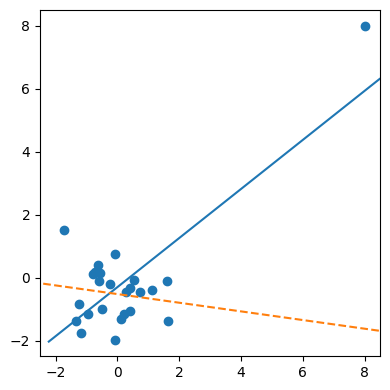

In [1]:
rng = np.random.default_rng(seed=5)
x = rng.normal(size=25)
y = -x / 5 + rng.normal(size=25)
x[0] = 8
y[0] = 8

def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y)
slope, intercept, _, _, _ = linregress(x, y)
ax.plot(*abline(slope, intercept, ax))
slope, intercept, _, _, _ = linregress(x[1:], y[1:])
ax.plot(*abline(slope, intercept, ax), "--")
ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)

plt.tight_layout()
plt.show()

## Figure 4-8. A histogram of the residuals from the regression of the housing data

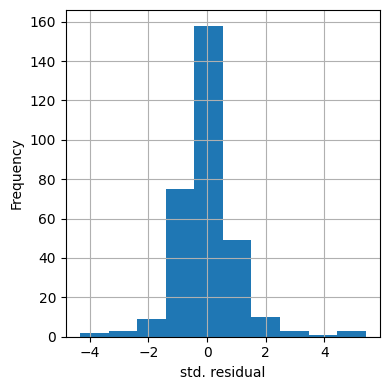

In [1]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel("std. residual")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Figure 4-10. A polynomial regression fit for the variable SqFtTotLiving
### (solid line) versus a smooth (dashed line; see the following section about splines)

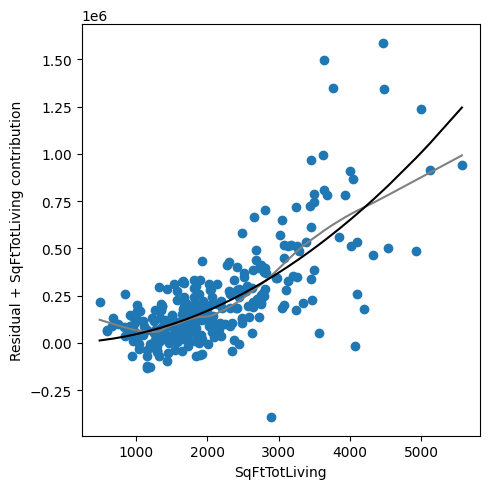

0.03879128168239703


In [1]:
def partial_residual_plot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    # determine columns required for model
    required = set(model.params.index).intersection(df.columns)
    required.add(feature)
    # create a copy of df with only required columns and set everything
    # except the features to zero
    copy_df = df[list(required)].copy().astype("float")
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        "feature": df[feature],
        "residual": df[outcome] - y_pred,
        "ypartial": feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=["feature"])
    smoothed = sm.nonparametric.lowess(results.ypartial + results.residual, results.feature,
        frac=1 / 3)

    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color="gray")
    ax.plot(results.feature, results.ypartial, color="black")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"Residual + {feature} contribution")
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partial_residual_plot(result_poly, house_98105, "AdjSalePrice", "SqFtTotLiving", ax)

plt.tight_layout()
plt.show()
print(result_poly.params.iloc[2])

## Figure 4-12. A spline regression fit for the variable SqFtTotLiving (solid line) compared to a smooth (dashed line)

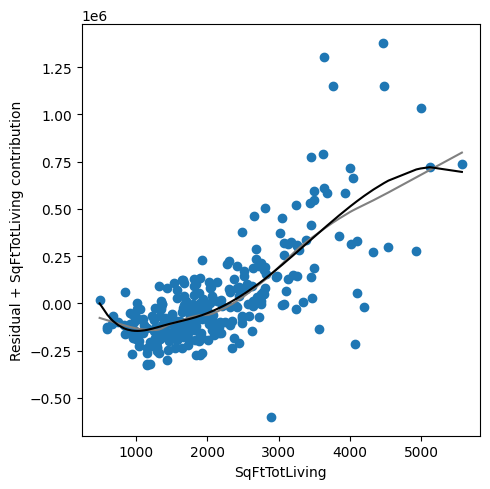

In [1]:
fig, ax = plt.subplots(figsize=(5, 5))
partial_residual_plot(result_spline, house_98105, "AdjSalePrice", "SqFtTotLiving", ax)

plt.tight_layout()
plt.show()

## Figure 4-13. A GAM regression fit for the variable SqFtTotLiving (solid line) compared to a smooth (dashed line)

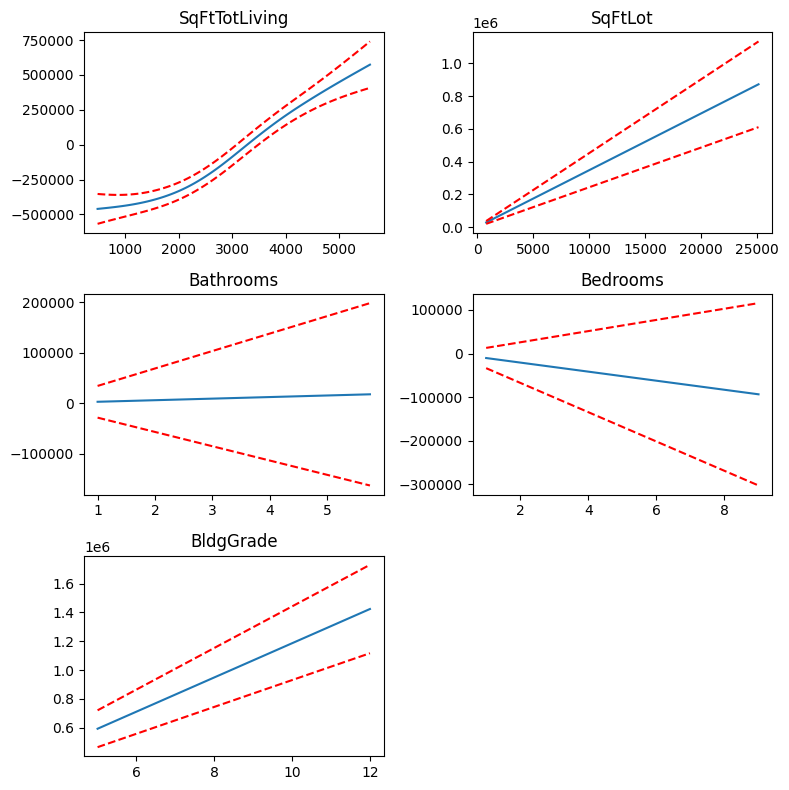

In [1]:
fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)

titles = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c="r", ls="--")
    ax.set_title(title)

axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

## Generalized additive models using statsmodels

In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"

x_spline = house_98105[predictors]
bs = BSplines(x_spline, df=[10] + [3] * 4, degree=[3] + [2] * 4)
# penalization weight
alpha = np.array([0] * 5)

formula = ("AdjSalePrice ~ SqFtTotLiving + "
           "SqFtLot + Bathrooms + Bedrooms + BldgGrade")

gam_sm = GLMGam.from_formula(formula, data=house_98105, smoother=bs, alpha=alpha)
res_sm = gam_sm.fit()
print(res_sm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           AdjSalePrice   No. Observations:                  313
Model:                         GLMGam   Df Residuals:                   295.00
Model Family:                Gaussian   Df Model:                        17.00
Link Function:               Identity   Scale:                      2.7471e+10
Method:                         PIRLS   Log-Likelihood:                -4196.6
Date:                Tue, 09 Jun 2026   Deviance:                   8.1039e+12
Time:                        18:18:24   Pearson chi2:                 8.10e+12
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9901
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -3.481e+05   1.18e+05  

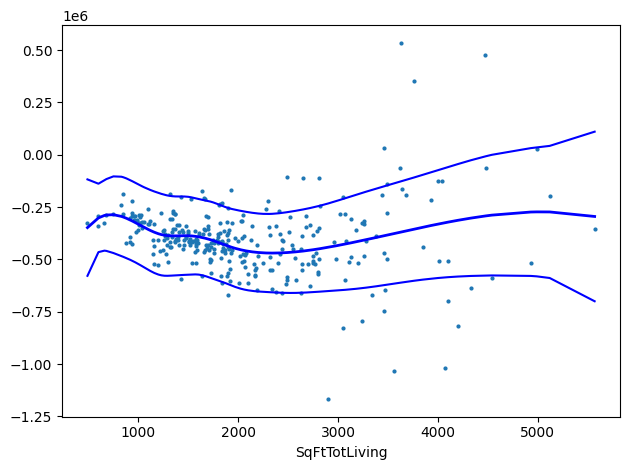

In [1]:
res_sm.plot_partial(0, cpr=True)

plt.tight_layout()
plt.show()

## Additional material not covered in book
### Regularization - Lasso

In [1]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms",
              "BldgGrade", "PropertyType", "NbrLivingUnits",
              "SqFtFinBasement", "YrBuilt", "YrRenovated",
              "NewConstruction"]
outcome = "AdjSalePrice"

X = pd.get_dummies(house[predictors], drop_first=True)
X["NewConstruction"] = [1 if nc else 0 for nc in X["NewConstruction"]]
columns = X.columns
X = StandardScaler().fit_transform(X)
y = house[outcome]

house_lm = LinearRegression()
print(house_lm.fit(X, y))

LinearRegression()


In [1]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X, y))

Lasso(alpha=10)


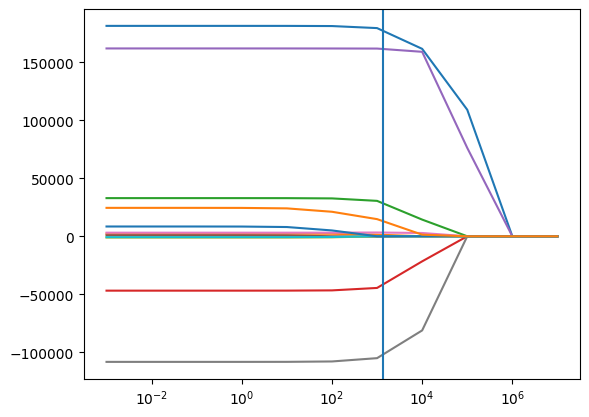

In [1]:
Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X, y)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X, y)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
plt.show()

In [1]:
# Note that some of the coefficients are shrunk to zero
pd.DataFrame({
    "name": columns,
    "coef": modelCV.coef_,
})

,name,coef
0,SqFtTotLiving,178995.820585
1,SqFtLot,1110.585770
2,Bathrooms,29843.352268
3,Bedrooms,-43790.256319
4,BldgGrade,161882.297251
5,NbrLivingUnits,-0.000000
6,SqFtFinBasement,3248.457098
7,YrBuilt,-104164.720862
8,YrRenovated,0.000000
9,NewConstruction,-0.000000
